# IMC Prosperity Log Analyzer

Parse and visualize a submission log file. Set the `LOG_PATH` and `PRODUCT` below, then run all cells.

**Outputs:**
- Per-timestamp master table: FV, best bid/ask, position, orders placed, actual fills, PnL
- Price + FV overlay plot with order markers
- Position and PnL over time
- Fill rate analysis
- Filter for 'interesting' ticks (fills, position extremes, etc)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path
import prosperity4

# === CONFIG ===
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round4" / "logs"
LOG_PATH = DATA_FOLDER / "509879.log.txt"
# "INTARIAN_PEPPER_ROOT"
PRODUCT = "VELVETFRUIT_EXTRACT"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

## 1. Load the log file

In [2]:
with open(LOG_PATH) as f:
    raw = json.load(f)

print(f"Submission ID: {raw['submissionId']}")
print(f"Lambda log entries: {len(raw['logs'])}")
print(f"Trade history entries: {len(raw['tradeHistory'])}")
print(f"Activity log size: {len(raw['activitiesLog'])} chars")

Submission ID: 7630a635-e415-4320-b28f-20d75bc7bd81
Lambda log entries: 1000
Trade history entries: 2118
Activity log size: 728783 chars


## 2. Parse the activities log (market state)

One row per product per timestamp. Gives us best bid/ask/volume, mid price, running PnL.

In [3]:
activities = pd.read_csv(StringIO(raw["activitiesLog"]), sep=";")
activities = activities[activities["product"] == PRODUCT].copy()
activities = activities.sort_values("timestamp").reset_index(drop=True)
print(f"Activity rows for {PRODUCT}: {len(activities)}")
activities.head()

Activity rows for VELVETFRUIT_EXTRACT: 1000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,3,0,VELVETFRUIT_EXTRACT,5293,64,NaN,NaN,NaN,NaN,5298,22,5299.0,42.0,NaN,NaN,5295.5,0.0
1,3,100,VELVETFRUIT_EXTRACT,5294,16,5293.0,37.0,NaN,NaN,5299,53,NaN,NaN,NaN,NaN,5296.5,0.0
2,3,200,VELVETFRUIT_EXTRACT,5294,20,5293.0,42.0,NaN,NaN,5299,20,5300.0,42.0,NaN,NaN,5296.5,0.0
3,3,300,VELVETFRUIT_EXTRACT,5294,23,5293.0,42.0,NaN,NaN,5299,23,5300.0,42.0,NaN,NaN,5296.5,0.0
4,3,400,VELVETFRUIT_EXTRACT,5293,15,5292.0,47.0,NaN,NaN,5298,15,5299.0,47.0,NaN,NaN,5295.5,0.0


## 3. Parse the lambda logs (your `self.log()` output)

Extracts whatever you printed inside `get_orders()` — FV, POS, SPREAD, and BUY/SELL entries. Supports both old format (single dict, overwriting) and new list-based format.

In [4]:
def parse_lambda_logs(raw_logs, product):
    rows = []
    for entry in raw_logs:
        lamb = entry.get("lambdaLog", "")
        if not lamb:
            continue
        try:
            parsed = json.loads(lamb)
        except json.JSONDecodeError:
            continue

        prod = parsed.get(product, {})
        row = {"timestamp": entry["timestamp"]}

        # Copy all scalar fields
        for k, v in prod.items():
            if k in ("BUY", "SELL", "BUYS", "SELLS"):
                continue
            row[k] = v

        # Orders placed — support list or single-dict formats
        buys_field = prod.get("BUYS")
        sells_field = prod.get("SELLS")
        buy_field = prod.get("BUY")
        sell_field = prod.get("SELL")

        placed_buys = buys_field if isinstance(buys_field, list) else ([buy_field] if buy_field else [])
        placed_sells = sells_field if isinstance(sells_field, list) else ([sell_field] if sell_field else [])

        row["placed_buys"] = placed_buys
        row["placed_sells"] = placed_sells
        row["n_buys_placed"] = len(placed_buys)
        row["n_sells_placed"] = len(placed_sells)
        row["total_buy_vol"] = sum(b.get("v", 0) for b in placed_buys)
        row["total_sell_vol"] = sum(s.get("v", 0) for s in placed_sells)

        rows.append(row)

    return pd.DataFrame(rows)

lambda_df = parse_lambda_logs(raw["logs"], PRODUCT)
print(f"Lambda log rows: {len(lambda_df)}")
lambda_df.head()

Lambda log rows: 1000


,timestamp,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol
0,0,[],[],0,0,0,0
1,100,[],[],0,0,0,0
2,200,[],[],0,0,0,0
3,300,[],[],0,0,0,0
4,400,[],[],0,0,0,0


## 4. Parse the trade history (actual fills)

`SUBMISSION` as buyer = we bought. `SUBMISSION` as seller = we sold. Others = bot-to-bot trades.

In [5]:
trades = pd.DataFrame(raw["tradeHistory"])
trades = trades[trades["symbol"] == PRODUCT].copy()

def classify(row):
    if row["buyer"] == "SUBMISSION":
        return "our_buy"
    elif row["seller"] == "SUBMISSION":
        return "our_sell"
    else:
        return "other"

trades["kind"] = trades.apply(classify, axis=1)
trades["signed_qty"] = trades.apply(
    lambda r: r["quantity"] if r["kind"] == "our_buy" else (-r["quantity"] if r["kind"] == "our_sell" else 0),
    axis=1
)
print(f"Total trades: {len(trades)}")
print(trades["kind"].value_counts())
trades.head()

Total trades: 66
kind
our_buy     29
our_sell    21
other       16
Name: count, dtype: int64


,timestamp,buyer,seller,symbol,currency,price,quantity,kind,signed_qty
44,2600,SUBMISSION,Mark 22,VELVETFRUIT_EXTRACT,XIRECS,5295.0,5,our_buy,5
110,6300,SUBMISSION,Mark 49,VELVETFRUIT_EXTRACT,XIRECS,5295.0,10,our_buy,10
111,6300,Mark 14,SUBMISSION,VELVETFRUIT_EXTRACT,XIRECS,5294.0,20,our_sell,-20
120,6600,SUBMISSION,Mark 49,VELVETFRUIT_EXTRACT,XIRECS,5296.0,12,our_buy,12
121,6600,Mark 14,SUBMISSION,VELVETFRUIT_EXTRACT,XIRECS,5295.0,2,our_sell,-2


In [6]:
# Aggregate our fills per timestamp
our_trades = trades[trades["kind"].isin(["our_buy", "our_sell"])].copy()

fills_per_ts = (
    our_trades.groupby(["timestamp", "kind"])
    .agg(price_avg=("price", "mean"), qty_total=("quantity", "sum"))
    .unstack("kind", fill_value=0)
)
fills_per_ts.columns = [f"{a}_{b}" for a, b in fills_per_ts.columns]
fills_per_ts = fills_per_ts.reset_index()
print(f"Timestamps with fills: {len(fills_per_ts)}")
fills_per_ts.head()

Timestamps with fills: 41


,timestamp,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell
0,2600,5295.0,0.0,5,0
1,6300,5295.0,5294.0,10,20
2,6600,5296.0,5295.0,12,2
3,12600,5292.0,0.0,60,0
4,12800,5291.0,0.0,16,0


## 5. Build the master table

One row per timestamp: market state + your logged values + placed orders + actual fills.

In [7]:
df = activities[["timestamp", "bid_price_1", "bid_volume_1", "ask_price_1", "ask_volume_1",
                 "mid_price", "profit_and_loss"]].copy()
df = df.rename(columns={"bid_price_1": "best_bid", "ask_price_1": "best_ask",
                        "bid_volume_1": "bid_vol", "ask_volume_1": "ask_vol",
                        "profit_and_loss": "pnl"})

df = df.merge(lambda_df, on="timestamp", how="left")
df = df.merge(fills_per_ts, on="timestamp", how="left")

for col in ["qty_total_our_buy", "qty_total_our_sell"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df["spread"] = df["best_ask"] - df["best_bid"]

print(f"Master table shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head(150))

Master table shape: (1000, 18)
Columns: ['timestamp', 'best_bid', 'bid_vol', 'best_ask', 'ask_vol', 'mid_price', 'pnl', 'placed_buys', 'placed_sells', 'n_buys_placed', 'n_sells_placed', 'total_buy_vol', 'total_sell_vol', 'price_avg_our_buy', 'price_avg_our_sell', 'qty_total_our_buy', 'qty_total_our_sell', 'spread']


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread
0,0,5293,64,5298,22,5295.5,0.00000,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
1,100,5294,16,5299,53,5296.5,0.00000,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
2,200,5294,20,5299,20,5296.5,0.00000,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
3,300,5294,23,5299,23,5296.5,0.00000,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
4,400,5293,15,5298,15,5295.5,0.00000,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,14500,5288,23,5293,23,5290.5,-160.65625,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
146,14600,5287,23,5292,67,5289.5,-256.28125,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
147,14700,5288,48,5293,18,5290.5,-118.00000,[],[],0,0,0,0,NaN,NaN,0.0,0.0,5
148,14800,5292,15,5294,23,5293.0,-59.71875,[],[],0,0,0,0,NaN,NaN,0.0,0.0,2


## 6. Main analysis table

Key fields per timestamp. Orders shown as `volume@price`.

In [23]:
def format_orders(orders):
    if not isinstance(orders, list) or len(orders) == 0:
        return ""
    return ", ".join(f"{o.get('v', '?')}@{o.get('p', '?')}" for o in orders)

display_df = df.copy()
display_df["buys"] = display_df["placed_buys"].apply(format_orders)
display_df["sells"] = display_df["placed_sells"].apply(format_orders)

available = set(display_df.columns)
want = ["timestamp", "best_bid", "best_ask", "spread", "mid_price"]
for opt in ["FV", "POS", "ZSCORE", "SKEW_SHIFT"]:
    if opt in available:
        want.append(opt)
want += ["buys", "sells"]
if "qty_total_our_buy" in available:
    want += ["qty_total_our_buy", "qty_total_our_sell"]
want += ["pnl"]

final_cols = [c for c in want if c in available]
display_df[final_cols].head(10)

,timestamp,best_bid,best_ask,spread,mid_price,buys,sells,pnl
0,0,102,106,4,104.0,,,0.0
1,100,101,105,4,103.0,,,0.0
2,200,102,105,3,103.5,,,0.0
3,300,102,105,3,103.5,,,0.0
4,400,101,104,3,102.5,,,0.0
5,500,100,103,3,101.5,,,0.0
6,600,100,102,2,101.0,,,0.0
7,700,99,102,3,100.5,,,0.0
8,800,100,103,3,101.5,,,0.0
9,900,100,103,3,101.5,,,0.0


In [24]:
# Export to CSV for offline analysis
# df.to_csv("log_analysis.csv", index=False)
# print("Saved to log_analysis.csv")

## 7. Price, FV, and fills overlay

Mid price + best bid/ask + your FV estimate. Green triangles = our buys. Red triangles = our sells.

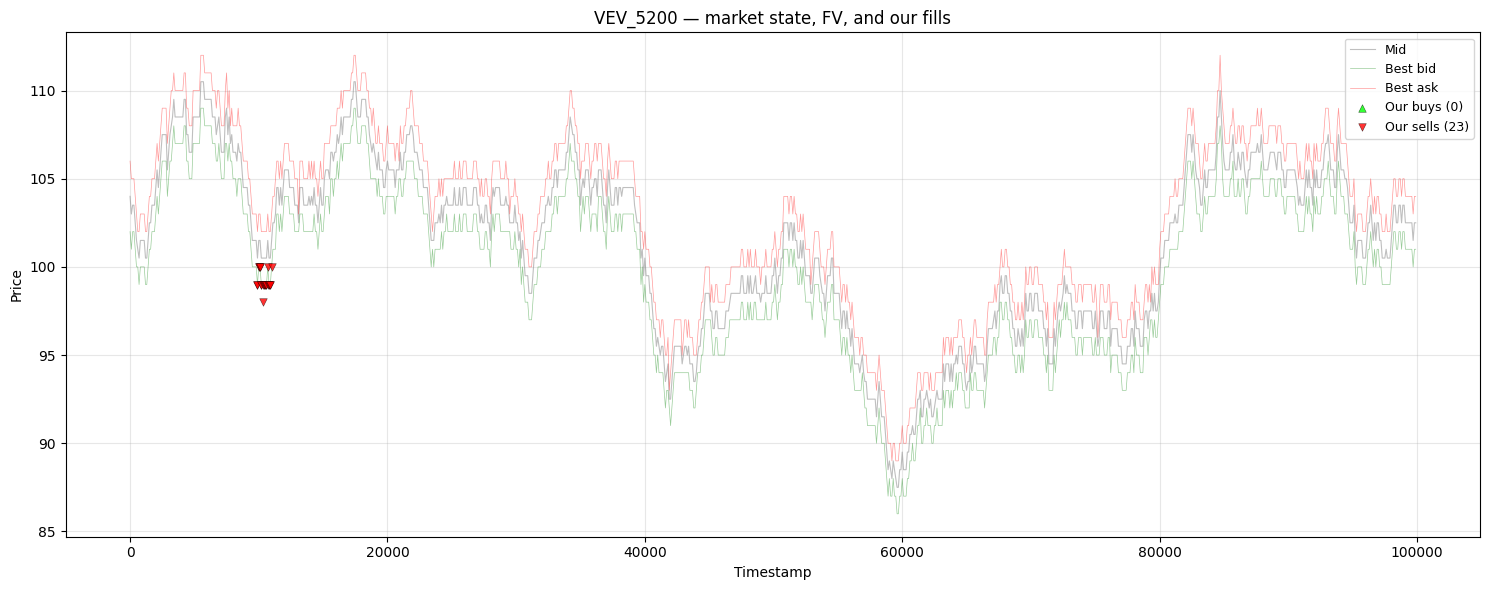

In [25]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df["timestamp"], df["mid_price"].replace(0, np.nan), color="gray", alpha=0.5, linewidth=0.8, label="Mid")
ax.plot(df["timestamp"], df["best_bid"].replace(0, np.nan), color="green", alpha=0.4, linewidth=0.5, label="Best bid")
ax.plot(df["timestamp"], df["best_ask"].replace(0, np.nan), color="red", alpha=0.4, linewidth=0.5, label="Best ask")

if "FV" in df.columns:
    ax.plot(df["timestamp"], df["FV"], color="blue", linewidth=1.2, label="FV (your estimate)")

our_buys = our_trades[our_trades["kind"] == "our_buy"]
our_sells = our_trades[our_trades["kind"] == "our_sell"]
ax.scatter(our_buys["timestamp"], our_buys["price"], marker="^", color="lime",
           s=30, alpha=0.8, label=f"Our buys ({len(our_buys)})", zorder=5, edgecolors="black", linewidths=0.3)
ax.scatter(our_sells["timestamp"], our_sells["price"], marker="v", color="red",
           s=30, alpha=0.8, label=f"Our sells ({len(our_sells)})", zorder=5, edgecolors="black", linewidths=0.3)

ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
# ax.set_ylim(9980, 10020)
ax.set_title(f"{PRODUCT} \u2014 market state, FV, and our fills")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Position and PnL over time

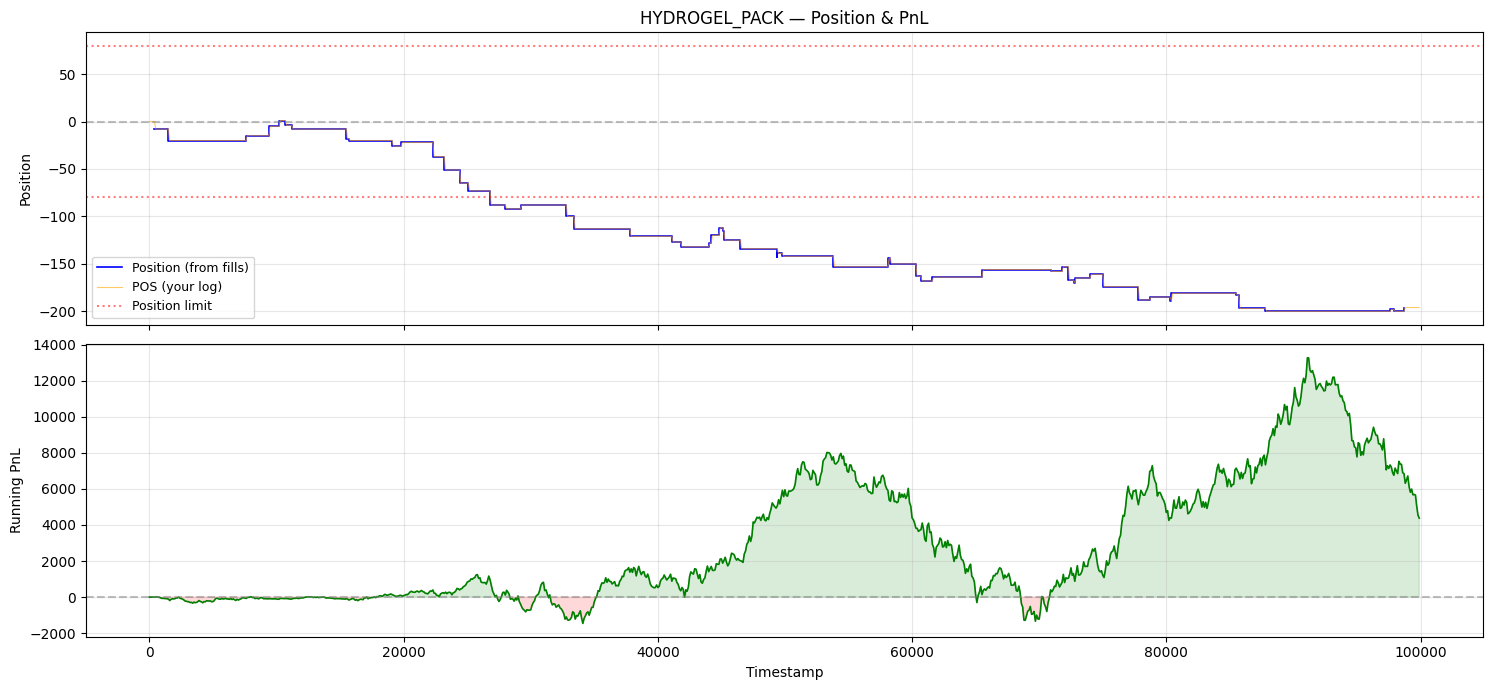

Final PnL:     4376.62
Max drawdown:  -9352.75
Total trades:  56 (19 buys, 37 sells)


In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

our_trades_sorted = our_trades.sort_values("timestamp").copy()
our_trades_sorted["running_pos"] = our_trades_sorted["signed_qty"].cumsum()

ax1.step(our_trades_sorted["timestamp"], our_trades_sorted["running_pos"], where="post",
         color="blue", linewidth=1.2, label="Position (from fills)")
if "POS" in df.columns:
    ax1.plot(df["timestamp"], df["POS"], color="orange", alpha=0.6, linewidth=0.8, label="POS (your log)")

ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax1.axhline(80, color="red", linestyle=":", alpha=0.5, label="Position limit")
ax1.axhline(-80, color="red", linestyle=":", alpha=0.5)
ax1.set_ylabel("Position")
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_title(f"{PRODUCT} \u2014 Position & PnL")

ax2.plot(df["timestamp"], df["pnl"], color="green", linewidth=1.2)
ax2.fill_between(df["timestamp"], 0, df["pnl"], where=df["pnl"]>=0, color="green", alpha=0.15)
ax2.fill_between(df["timestamp"], 0, df["pnl"], where=df["pnl"]<0, color="red", alpha=0.15)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Running PnL")
ax2.set_xlabel("Timestamp")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final PnL:     {df['pnl'].iloc[-1]:.2f}")
print(f"Max drawdown:  {(df['pnl'] - df['pnl'].cummax()).min():.2f}")
print(f"Total trades:  {len(our_trades)} ({len(our_buys)} buys, {len(our_sells)} sells)")

## 9. Fill rate analysis

For each placed order, did we get filled?

In [42]:
fill_df = df[["timestamp", "total_buy_vol", "total_sell_vol"]].copy()
if "qty_total_our_buy" in df.columns:
    fill_df["filled_buy_vol"] = df["qty_total_our_buy"]
    fill_df["filled_sell_vol"] = df["qty_total_our_sell"]
else:
    fill_df["filled_buy_vol"] = 0
    fill_df["filled_sell_vol"] = 0

fill_df["buy_fill_rate"] = np.where(fill_df["total_buy_vol"] > 0,
                                     fill_df["filled_buy_vol"] / fill_df["total_buy_vol"], np.nan)
fill_df["sell_fill_rate"] = np.where(fill_df["total_sell_vol"] > 0,
                                      fill_df["filled_sell_vol"] / fill_df["total_sell_vol"], np.nan)

total_placed_buy = fill_df['total_buy_vol'].sum()
total_placed_sell = fill_df['total_sell_vol'].sum()
total_filled_buy = fill_df['filled_buy_vol'].sum()
total_filled_sell = fill_df['filled_sell_vol'].sum()

print("Overall fill rates:")
print(f"  Buy side:  placed {total_placed_buy} units, filled {total_filled_buy} "
      f"({total_filled_buy / max(total_placed_buy, 1) * 100:.1f}%)")
print(f"  Sell side: placed {total_placed_sell} units, filled {total_filled_sell} "
      f"({total_filled_sell / max(total_placed_sell, 1) * 100:.1f}%)")

print("\nFill rate by side (per-tick avg):")
print(f"  Buy:  {fill_df['buy_fill_rate'].mean() * 100:.1f}% of placed volume per tick")
print(f"  Sell: {fill_df['sell_fill_rate'].mean() * 100:.1f}% of placed volume per tick")

Overall fill rates:
  Buy side:  placed 306730 units, filled 105.0 (0.0%)
  Sell side: placed 77961 units, filled 301.0 (0.4%)

Fill rate by side (per-tick avg):
  Buy:  1.3% of placed volume per tick
  Sell: 3.0% of placed volume per tick


## 10. Drill into specific ticks

Default filter: only ticks where we had fills. Edit the filter to inspect other interesting moments (position at limit, high z-score, etc).

In [16]:
interesting = df[(df.get("qty_total_our_buy", 0) > 0) | (df.get("qty_total_our_sell", 0) > 0)].copy()
interesting["buys"] = interesting["placed_buys"].apply(format_orders)
interesting["sells"] = interesting["placed_sells"].apply(format_orders)

show_cols = ["timestamp", "best_bid", "best_ask"]
if "FV" in interesting.columns: show_cols.append("FV")
if "POS" in interesting.columns: show_cols.append("POS")
show_cols += ["buys", "sells"]
if "qty_total_our_buy" in interesting.columns: show_cols += ["qty_total_our_buy", "qty_total_our_sell"]
show_cols.append("pnl")

show_cols = [c for c in show_cols if c in interesting.columns]
print(f"Ticks with fills: {len(interesting)}")
interesting[show_cols].head(50)

Ticks with fills: 212


,timestamp,best_bid,best_ask,FV,POS,buys,sells,qty_total_our_buy,qty_total_our_sell,pnl
32,3200,10022,10038,10029.5,0,,12@10022,0.0,12.0,0.000000
33,3300,10021,10037,10029.0,-12,,12@10021,0.0,12.0,-83.937500
34,3400,10023,10039,10031.5,-24,,11@10023,0.0,11.0,-235.156250
36,3600,10022,10038,10030.5,-35,,10@10022,0.0,10.0,-285.000000
52,5200,10011,10027,10019.5,-45,15@10027,,15.0,0.0,126.031250
53,5300,10010,10026,10017.5,-30,15@10026,,15.0,0.0,53.375000
54,5400,10011,10027,10018.5,-15,14@10027,,14.0,0.0,-87.031250
55,5500,10012,10028,10020.5,-1,13@10028,,13.0,0.0,-204.138672
65,6500,10013,10029,10021.5,12,,13@10013,0.0,13.0,-292.593750
66,6600,10011,10028,10019.5,-1,15@10028,,15.0,0.0,-398.492188


### Other useful filters

Uncomment any of these to explore different slices:

In [17]:
# At position limit
df[df.get("POS", pd.Series(0)).abs() >= 80].head(20)

# Ticks where FV diverged from mid
if "FV" in df.columns:
    df["fv_resid"] = df["FV"] - df["mid_price"]
    df[df["fv_resid"].abs() > 2].head(20)

# Largest single-tick PnL changes (worst and best)
df["pnl_delta"] = df["pnl"].diff()
print("Biggest PnL drops:"); display(df.nsmallest(10, "pnl_delta"))
print("Biggest PnL gains:"); display(df.nlargest(10, "pnl_delta"))

# Narrow spread events (potential taking opportunities)
df[df["spread"] < 10].head(20)

Biggest PnL drops:


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,POS,FV,SMA,DIST,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread,fv_resid,pnl_delta
475,47500,9957,11,9973,11,9965.0,-11324.750,200,9965.5,9985.60,-20.10,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,-1170.750
570,57000,9938,12,9954,12,9946.0,-15166.000,168,9946.5,9950.58,-4.08,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,-1070.250
911,91100,9907,10,9923,10,9915.0,-33864.250,200,9915.0,9943.77,-28.77,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.0,-983.250
688,68800,9989,12,10005,12,9997.0,-23306.500,-200,9996.5,9974.36,22.14,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,-0.5,-925.375
854,85400,9939,10,9954,10,9946.5,-27563.000,200,9946.5,9955.98,-9.48,[],[],0,0,0,0,NaN,NaN,0.0,0.0,15,0.0,-883.000
769,76900,9946,13,9962,13,9954.0,-26033.500,200,9954.5,9981.40,-26.90,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,-869.500
650,65000,9979,15,9995,15,9987.0,-21489.125,-200,9987.5,9961.21,26.29,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,-855.500
530,53000,9933,14,9949,14,9941.0,-16116.500,200,9941.5,9966.17,-24.67,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,-818.500
616,61600,9962,13,9970,4,9966.0,-18094.625,-200,9970.5,9950.43,20.07,[],[],0,0,0,0,NaN,NaN,0.0,0.0,8,4.5,-813.875
901,90100,9915,14,9931,14,9923.0,-32212.500,200,9923.5,9947.31,-23.81,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,-809.250


Biggest PnL gains:


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,POS,FV,SMA,DIST,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread,fv_resid,pnl_delta
702,70200,9980,14,9996,14,9988.0,-21638.750,-200,9988.5,9979.72,8.78,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,1014.250
867,86700,9942,15,9958,15,9950.0,-26864.375,200,9950.0,9952.99,-2.99,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.0,1007.875
896,89600,9925,12,9941,12,9933.0,-30194.625,200,9933.5,9948.74,-15.24,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,978.500
525,52500,9942,12,9958,12,9950.0,-14257.000,200,9950.5,9968.15,-17.65,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,802.250
612,61200,9956,11,9972,11,9964.0,-16637.250,-168,9964.5,9949.47,15.03,[],"[{'p': 9956, 'v': 11}]",0,1,0,11,0.0,9956.0,0.0,11.0,16,0.5,745.625
793,79300,9947,13,9963,13,9955.0,-25932.375,200,9954.5,9973.26,-18.76,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,-0.5,733.125
946,94600,9930,10,9946,10,9938.0,-29455.500,186,9938.0,9933.32,4.68,[],"[{'p': 9930, 'v': 10}]",0,1,0,10,0.0,9930.0,0.0,10.0,16,0.0,719.000
811,81100,9950,10,9966,10,9958.0,-25210.250,200,9958.5,9967.13,-8.63,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,708.000
817,81700,9952,14,9968,14,9960.0,-24872.625,200,9959.5,9965.53,-6.03,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,-0.5,706.375
270,27000,9985,11,10001,11,9993.0,-6135.375,200,9993.5,10004.27,-10.77,[],[],0,0,0,0,NaN,NaN,0.0,0.0,16,0.5,682.000


,timestamp,best_bid,bid_vol,best_ask,ask_vol,mid_price,pnl,POS,FV,SMA,DIST,placed_buys,placed_sells,n_buys_placed,n_sells_placed,total_buy_vol,total_sell_vol,price_avg_our_buy,price_avg_our_sell,qty_total_our_buy,qty_total_our_sell,spread,fv_resid,pnl_delta
4,400,10011,8,10019,12,10015.0,0.000000,0,10011.5,10012.00,-0.50,[],[],0,0,0,0,NaN,NaN,0.0,0.0,8,-3.5,0.000000
15,1500,10017,12,10024,4,10020.5,0.000000,0,10024.5,10015.56,8.94,[],[],0,0,0,0,NaN,NaN,0.0,0.0,7,4.0,0.000000
76,7600,10010,14,10018,5,10014.0,-946.812500,7,10018.5,10021.10,-2.60,[],[],0,0,0,0,NaN,NaN,0.0,0.0,8,4.5,6.640625
94,9400,10011,10,10019,10,10015.0,-939.218750,7,10019.5,10020.32,-0.82,[],[],0,0,0,0,NaN,NaN,0.0,0.0,8,4.5,-3.453125
107,10700,10015,5,10023,13,10019.0,-1142.257812,4,10015.5,10021.18,-5.68,[],[],0,0,0,0,NaN,NaN,0.0,0.0,8,-3.5,7.296875
155,15500,10022,10,10031,10,10026.5,-1979.734375,-9,10022.5,10018.44,4.06,[],[],0,0,0,0,NaN,NaN,0.0,0.0,9,-4.0,30.601562
198,19800,10007,14,10015,4,10011.0,-2150.000000,0,10015.5,10018.81,-3.31,[],[],0,0,0,0,NaN,NaN,0.0,0.0,8,4.5,0.000000
223,22300,9994,15,10001,4,9997.5,-4050.000000,160,10001.5,10016.01,-14.51,"[{'p': 10001, 'v': 4}]",[],1,0,4,0,10001.0,0.0,4.0,0.0,7,4.0,-599.250000
232,23200,9996,14,10003,7,9999.5,-4065.250000,200,10003.5,10015.37,-11.87,[],[],0,0,0,0,NaN,NaN,0.0,0.0,7,4.0,188.875000
244,24400,9990,14,9997,9,9993.5,-5230.000000,200,9997.5,10013.47,-15.97,[],[],0,0,0,0,NaN,NaN,0.0,0.0,7,4.0,241.875000
